In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
bureau = pd.read_csv(r'C:\Projects_ciência_dados\project_credit_risk\data\raw\home-credit-default-risk\bureau.csv')

In [3]:
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [4]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [5]:
bureau.shape

(1716428, 17)

In [6]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [7]:
bureau.isnull().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
dtype: int64

Mediana de 4 clientes iguais

In [8]:
bureau.groupby('SK_ID_CURR').size().median()

np.float64(4.0)

In [9]:
bureau.groupby('CREDIT_TYPE').size().median()

np.float64(555.0)

In [10]:
np.unique(bureau['CREDIT_CURRENCY'], return_counts=True)

(array(['currency 1', 'currency 2', 'currency 3', 'currency 4'],
       dtype=object),
 array([1715020,    1224,     174,      10]))

In [11]:
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [12]:
np.unique(bureau['AMT_CREDIT_SUM_DEBT'], return_counts=True)

(array([-4.70560032e+06, -3.10951098e+06, -2.79672372e+06, ...,
         1.64032200e+08,  1.70100000e+08,             nan], shape=(226538,)),
 array([     1,      1,      1, ...,      1,      1, 257669],
       shape=(226538,)))

#### Agregações para as features

- Credit Active: quantidade de ativos e closed
- Credit currency: eliminar, pois está muito desbalanceada
- DAYS CREDIT: mediana, crédito mais antigo, crédito mais novo
- CREDIT_DAY_OVERDUE: mediana, maior atraso, menor atraso
- DAYS_CREDIT_ENDDATE: quantidade de atrasos, quantidade de não atrasos
- DAYS_ENDDATE_FACT: quantidade de atrasos, quantidade de não atrasos
- AMT_CREDIT_MAX_OVERDUE: mediana
- CNT_CREDIT_PROLONG: média para punir os maiores
- AMT_CREDIT_SUM: menor valor, maior valor, mediana
- AMT_CREDIT_SUM_DEBT: tem dívida?, valor da dívida
- AMT_CREDIT_SUM_LIMIT: não sei
- AMT_CREDIT_SUM_OVERDUE: tem valor vencido?, média valor vencido
- CREDIT_TYPE: não sei, pois não basta apenas a quantidade, é interessante saber como foi em cada uma


<Axes: xlabel='DAYS_CREDIT', ylabel='Count'>

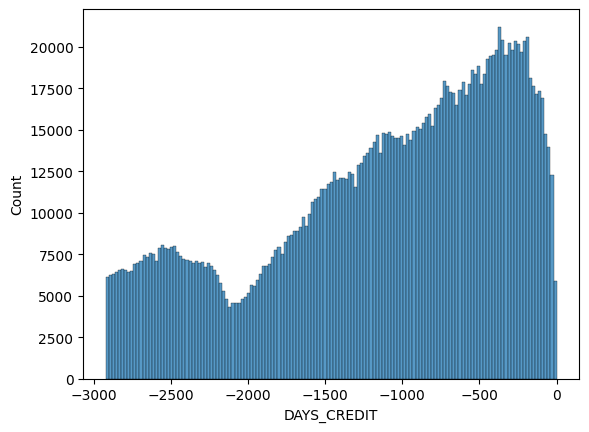

In [13]:
sns.histplot(data=bureau, x='DAYS_CREDIT')

In [14]:
(bureau['DAYS_CREDIT'].quantile(0.75)) - (bureau['DAYS_CREDIT'].quantile(0.25))

np.float64(1192.0)

In [15]:
bureau.groupby('SK_ID_CURR').agg({'DAYS_CREDIT':'median'})

,DAYS_CREDIT
SK_ID_CURR,
100001,-857.0
100002,-1042.5
100003,-1205.5
100004,-867.0
100005,-137.0
...,...
456249,-1680.0
456250,-824.0
456253,-919.0


In [16]:
np.unique(bureau['CREDIT_DAY_OVERDUE'], return_counts=True)

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
          11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
          22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
          33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
          44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
          55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
          66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
          77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
          88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
          99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
         110,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
         122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
         133,  134,  135,  136,  137,  138,  139,  140,  141,  142,  143,
         144,  146,  147,  148,  149, 

Agregando por ID e crédito, depois somando a quantidade de cada status de crédito e criando uma nova coluna

In [17]:
bureau_agg = bureau.groupby(['SK_ID_CURR', 'CREDIT_ACTIVE']).size().unstack(fill_value=0)

Renomeando

In [18]:
bureau_agg.columns = [
    f'n_credit_{c.lower().replace(" ", "_")}'
    for c in bureau_agg.columns
]


In [19]:
bureau_agg

,n_credit_active,n_credit_bad_debt,n_credit_closed,n_credit_sold
SK_ID_CURR,,,,
100001,3,0,4,0
100002,2,0,6,0
100003,1,0,3,0
100004,0,0,2,0
100005,2,0,1,0
...,...,...,...,...
456249,2,0,11,0
456250,2,0,1,0
456253,2,0,2,0


Feature Enginnering na coluna days credit

In [20]:
days_credit_agg = bureau.groupby('SK_ID_CURR')['DAYS_CREDIT'].agg(
    days_credit_median = 'median',
    days_credit_mais_antigo = 'min',
    days_credit_mais_novo ='max'
)

In [21]:
bureau_agg = bureau_agg.join(days_credit_agg)

In [22]:
bureau_agg

,n_credit_active,n_credit_bad_debt,n_credit_closed,n_credit_sold,days_credit_median,days_credit_mais_antigo,days_credit_mais_novo
SK_ID_CURR,,,,,,,
100001,3,0,4,0,-857.0,-1572,-49
100002,2,0,6,0,-1042.5,-1437,-103
100003,1,0,3,0,-1205.5,-2586,-606
100004,0,0,2,0,-867.0,-1326,-408
100005,2,0,1,0,-137.0,-373,-62
...,...,...,...,...,...,...,...
456249,2,0,11,0,-1680.0,-2713,-483
456250,2,0,1,0,-824.0,-1002,-760
456253,2,0,2,0,-919.0,-919,-713


In [23]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [24]:
credit_day_overdue = bureau.groupby('SK_ID_CURR')['CREDIT_DAY_OVERDUE'].agg(
    credit_days_overdue_median = 'median', # entender padrão de pagamento
    credit_days_overdue_max = 'max', # atraso máximo
    credit_days_overdue_mean = 'mean' # capturar oscilações
)

In [25]:
bureau_agg = bureau_agg.join(credit_day_overdue)

In [26]:
bureau_agg

,n_credit_active,n_credit_bad_debt,n_credit_closed,n_credit_sold,days_credit_median,days_credit_mais_antigo,days_credit_mais_novo,credit_days_overdue_median,credit_days_overdue_max,credit_days_overdue_mean
SK_ID_CURR,,,,,,,,,,
100001,3,0,4,0,-857.0,-1572,-49,0.0,0,0.0
100002,2,0,6,0,-1042.5,-1437,-103,0.0,0,0.0
100003,1,0,3,0,-1205.5,-2586,-606,0.0,0,0.0
100004,0,0,2,0,-867.0,-1326,-408,0.0,0,0.0
100005,2,0,1,0,-137.0,-373,-62,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
456249,2,0,11,0,-1680.0,-2713,-483,0.0,0,0.0
456250,2,0,1,0,-824.0,-1002,-760,0.0,0,0.0
456253,2,0,2,0,-919.0,-919,-713,0.0,0,0.0


In [27]:
n_overdue = (
    bureau
    .assign(is_overdue = bureau['CREDIT_DAY_OVERDUE'] > 0)
    .groupby('SK_ID_CURR')['is_overdue']
    .sum()
    .rename('n_credit_overdue')
)

bureau_agg = bureau_agg.join(n_overdue)


In [28]:
bureau_agg

,n_credit_active,n_credit_bad_debt,n_credit_closed,n_credit_sold,days_credit_median,days_credit_mais_antigo,days_credit_mais_novo,credit_days_overdue_median,credit_days_overdue_max,credit_days_overdue_mean,n_credit_overdue
SK_ID_CURR,,,,,,,,,,,
100001,3,0,4,0,-857.0,-1572,-49,0.0,0,0.0,0
100002,2,0,6,0,-1042.5,-1437,-103,0.0,0,0.0,0
100003,1,0,3,0,-1205.5,-2586,-606,0.0,0,0.0,0
100004,0,0,2,0,-867.0,-1326,-408,0.0,0,0.0,0
100005,2,0,1,0,-137.0,-373,-62,0.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
456249,2,0,11,0,-1680.0,-2713,-483,0.0,0,0.0,0
456250,2,0,1,0,-824.0,-1002,-760,0.0,0,0.0,0
456253,2,0,2,0,-919.0,-919,-713,0.0,0,0.0,0


In [29]:
prolong_agg = bureau.groupby('SK_ID_CURR')['CNT_CREDIT_PROLONG'].agg(
    prolong_median = 'median',
    prolong_max = 'max'
)

In [30]:
bureau_agg = bureau_agg.join(prolong_agg)

In [31]:
credit_sum_agg = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM'].agg(
    amt_credit_sum_median = 'median',
    amt_credit_sum_min = 'min',
    amt_credit_sum_max = 'max'
)

bureau_agg = bureau_agg.join(credit_sum_agg)

In [32]:
credit_sum_debt_agg = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT'].agg(
    credit_sum_debt_total = 'sum'
)

bureau_agg = bureau_agg.join(credit_sum_debt_agg)

In [33]:
credit_sum_overdue = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_OVERDUE'].agg(
    credit_sum_overdue_median = 'median',
    credit_sum_overdue_max = 'max'
)

bureau_agg = bureau_agg.join(credit_sum_overdue)

In [34]:
credit_sum_overdue = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_MAX_OVERDUE'].agg(
    credit_max_overdue_median = 'median',
    credit_max_overdue_max = 'max'
)

bureau_agg = bureau_agg.join(credit_sum_overdue)

In [35]:
amt_annuity_agg = bureau.groupby('SK_ID_CURR')['AMT_ANNUITY'].agg(
    amt_annuity_median = 'median',
    amt_annuity_max = 'max',
    amt_annuity_min = 'min'
)

bureau_agg = bureau_agg.join(amt_annuity_agg)

In [36]:
top_types = bureau['CREDIT_TYPE'].value_counts().head(5).index

credit_type_agg = (
    bureau[bureau['CREDIT_TYPE'].isin(top_types)]
    .groupby(['SK_ID_CURR', 'CREDIT_TYPE'])
    .size()
    .unstack(fill_value=0)
    .add_prefix('n_credit_type_')
)

bureau_agg = bureau_agg.join(credit_type_agg)


In [37]:
n_unique_types = (
    bureau.groupby('SK_ID_CURR')['CREDIT_TYPE']
    .nunique()
    .rename('n_unique_credit_types')
)

bureau_agg = bureau_agg.join(n_unique_types)


In [38]:
bureau_agg.columns

Index(['n_credit_active', 'n_credit_bad_debt', 'n_credit_closed',
       'n_credit_sold', 'days_credit_median', 'days_credit_mais_antigo',
       'days_credit_mais_novo', 'credit_days_overdue_median',
       'credit_days_overdue_max', 'credit_days_overdue_mean',
       'n_credit_overdue', 'prolong_median', 'prolong_max',
       'amt_credit_sum_median', 'amt_credit_sum_min', 'amt_credit_sum_max',
       'credit_sum_debt_total', 'credit_sum_overdue_median',
       'credit_sum_overdue_max', 'credit_max_overdue_median',
       'credit_max_overdue_max', 'amt_annuity_median', 'amt_annuity_max',
       'amt_annuity_min', 'n_credit_type_Car loan',
       'n_credit_type_Consumer credit', 'n_credit_type_Credit card',
       'n_credit_type_Microloan', 'n_credit_type_Mortgage',
       'n_unique_credit_types'],
      dtype='object')

In [39]:
bureau_agg

,n_credit_active,n_credit_bad_debt,n_credit_closed,n_credit_sold,days_credit_median,days_credit_mais_antigo,days_credit_mais_novo,credit_days_overdue_median,credit_days_overdue_max,credit_days_overdue_mean,...,credit_max_overdue_max,amt_annuity_median,amt_annuity_max,amt_annuity_min,n_credit_type_Car loan,n_credit_type_Consumer credit,n_credit_type_Credit card,n_credit_type_Microloan,n_credit_type_Mortgage,n_unique_credit_types
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,3,0,4,0,-857.0,-1572,-49,0.0,0,0.0,...,NaN,0.0,10822.5,0.000,0.0,7.0,0.0,0.0,0.0,1
100002,2,0,6,0,-1042.5,-1437,-103,0.0,0,0.0,...,5043.645,0.0,0.0,0.000,0.0,4.0,4.0,0.0,0.0,2
100003,1,0,3,0,-1205.5,-2586,-606,0.0,0,0.0,...,0.000,NaN,NaN,NaN,0.0,2.0,2.0,0.0,0.0,2
100004,0,0,2,0,-867.0,-1326,-408,0.0,0,0.0,...,0.000,NaN,NaN,NaN,0.0,2.0,0.0,0.0,0.0,1
100005,2,0,1,0,-137.0,-373,-62,0.0,0,0.0,...,0.000,0.0,4261.5,0.000,0.0,2.0,1.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456249,2,0,11,0,-1680.0,-2713,-483,0.0,0,0.0,...,18945.000,NaN,NaN,NaN,0.0,9.0,3.0,0.0,0.0,3
456250,2,0,1,0,-824.0,-1002,-760,0.0,0,0.0,...,0.000,51799.5,384147.0,27757.395,0.0,2.0,1.0,0.0,0.0,2
456253,2,0,2,0,-919.0,-919,-713,0.0,0,0.0,...,NaN,58369.5,58369.5,58369.500,0.0,3.0,1.0,0.0,0.0,2


Pre-processamento

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [41]:
numericas = bureau_agg.select_dtypes(include=['int','float']).columns

Imputação com a mediana

In [42]:
process_others = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='median'), numericas)
])

In [43]:
process_others.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{featur

In [44]:
bureau_processed_others = process_others.fit_transform(bureau_agg)

Imputação com a mediana e normalização com MinMaxScaler

In [45]:
process_low_variance = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ]), numericas)
])

In [46]:
process_low_variance.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [47]:
bureau_processed_low_variance = process_low_variance.fit_transform(bureau_agg)

Foi necessário fazer dois datasets, pois para o Low Variance é necessário que os dados estejam normalizados com MinMaxScaler, enquanto para as outras análises não é necessário que os dados estejam normalizados

In [48]:
bureau_processed_low_variance

,num__n_credit_active,num__n_credit_bad_debt,num__n_credit_closed,num__n_credit_sold,num__days_credit_median,num__days_credit_mais_antigo,num__days_credit_mais_novo,num__credit_days_overdue_median,num__credit_days_overdue_max,num__credit_days_overdue_mean,...,num__credit_max_overdue_max,num__amt_annuity_median,num__amt_annuity_max,num__amt_annuity_min,num__n_credit_type_Car loan,num__n_credit_type_Consumer credit,num__n_credit_type_Credit card,num__n_credit_type_Microloan,num__n_credit_type_Mortgage,num__n_unique_credit_types
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,0.09375,0.0,0.037037,0.0,0.706708,0.462012,0.983231,0.0,0.0,0.0,...,0.000000,0.000000,0.000091,0.000000,0.0,0.081395,0.000000,0.0,0.0,0.0
100002,0.06250,0.0,0.055556,0.0,0.643224,0.508214,0.964750,0.0,0.0,0.0,...,0.000043,0.000000,0.000000,0.000000,0.0,0.046512,0.181818,0.0,0.0,0.2
100003,0.03125,0.0,0.027778,0.0,0.587440,0.114990,0.792608,0.0,0.0,0.0,...,0.000000,0.000109,0.000114,0.000000,0.0,0.023256,0.090909,0.0,0.0,0.2
100004,0.00000,0.0,0.018519,0.0,0.703285,0.546201,0.860370,0.0,0.0,0.0,...,0.000000,0.000109,0.000114,0.000000,0.0,0.023256,0.000000,0.0,0.0,0.0
100005,0.06250,0.0,0.009259,0.0,0.953114,0.872348,0.978782,0.0,0.0,0.0,...,0.000000,0.000000,0.000036,0.000000,0.0,0.023256,0.045455,0.0,0.0,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456249,0.06250,0.0,0.101852,0.0,0.425051,0.071526,0.834702,0.0,0.0,0.0,...,0.000163,0.000109,0.000114,0.000000,0.0,0.104651,0.136364,0.0,0.0,0.4
456250,0.06250,0.0,0.009259,0.0,0.718001,0.657084,0.739904,0.0,0.0,0.0,...,0.000000,0.001899,0.003243,0.001156,0.0,0.023256,0.045455,0.0,0.0,0.2
456253,0.06250,0.0,0.018519,0.0,0.685489,0.685489,0.755989,0.0,0.0,0.0,...,0.000000,0.002139,0.000493,0.002430,0.0,0.034884,0.045455,0.0,0.0,0.2


Nulos

In [49]:
bureau_processed_others.isnull().sum()

imputer__n_credit_active                  0
imputer__n_credit_bad_debt                0
imputer__n_credit_closed                  0
imputer__n_credit_sold                    0
imputer__days_credit_median               0
imputer__days_credit_mais_antigo          0
imputer__days_credit_mais_novo            0
imputer__credit_days_overdue_median       0
imputer__credit_days_overdue_max          0
imputer__credit_days_overdue_mean         0
imputer__n_credit_overdue                 0
imputer__prolong_median                   0
imputer__prolong_max                      0
imputer__amt_credit_sum_median            0
imputer__amt_credit_sum_min               0
imputer__amt_credit_sum_max               0
imputer__credit_sum_debt_total            0
imputer__credit_sum_overdue_median        0
imputer__credit_sum_overdue_max           0
imputer__credit_max_overdue_median        0
imputer__credit_max_overdue_max           0
imputer__amt_annuity_median               0
imputer__amt_annuity_max        

In [50]:
bureau_processed_low_variance.isnull().sum()

num__n_credit_active                  0
num__n_credit_bad_debt                0
num__n_credit_closed                  0
num__n_credit_sold                    0
num__days_credit_median               0
num__days_credit_mais_antigo          0
num__days_credit_mais_novo            0
num__credit_days_overdue_median       0
num__credit_days_overdue_max          0
num__credit_days_overdue_mean         0
num__n_credit_overdue                 0
num__prolong_median                   0
num__prolong_max                      0
num__amt_credit_sum_median            0
num__amt_credit_sum_min               0
num__amt_credit_sum_max               0
num__credit_sum_debt_total            0
num__credit_sum_overdue_median        0
num__credit_sum_overdue_max           0
num__credit_max_overdue_median        0
num__credit_max_overdue_max           0
num__amt_annuity_median               0
num__amt_annuity_max                  0
num__amt_annuity_min                  0
num__n_credit_type_Car loan           0


Low Variance

In [51]:
from sklearn.feature_selection import VarianceThreshold

In [52]:
var_bureau = bureau_processed_low_variance.var().sort_values()
var_bureau

num__credit_max_overdue_median        0.000004
num__amt_annuity_min                  0.000005
num__credit_max_overdue_max           0.000006
num__credit_sum_overdue_median        0.000006
num__amt_annuity_median               0.000009
num__amt_annuity_max                  0.000011
num__credit_sum_overdue_max           0.000013
num__amt_credit_sum_max               0.000016
num__amt_credit_sum_min               0.000016
num__amt_credit_sum_median            0.000017
num__credit_sum_debt_total            0.000023
num__n_credit_type_Microloan          0.000048
num__credit_days_overdue_median       0.000055
num__n_credit_bad_debt                0.000069
num__prolong_median                   0.000073
num__credit_days_overdue_mean         0.000081
num__n_credit_sold                    0.000309
num__n_credit_overdue                 0.000347
num__n_credit_type_Mortgage           0.000405
num__prolong_max                      0.000615
num__credit_days_overdue_max          0.000939
num__n_credit

In [53]:
var_bureau.describe()

count    30.000000
mean      0.006542
std       0.018237
min       0.000004
25%       0.000016
50%       0.000077
75%       0.001177
max       0.086475
dtype: float64

In [54]:
selecao = VarianceThreshold(0.000016)

In [55]:
low_variance = selecao.fit_transform(bureau_processed_low_variance)

In [56]:
feature_abaixo_threshold = bureau_processed_low_variance.loc[:, ~selecao.get_support()]

In [57]:
feature_abaixo_threshold

,num__amt_credit_sum_max,num__credit_sum_overdue_median,num__credit_sum_overdue_max,num__credit_max_overdue_median,num__credit_max_overdue_max,num__amt_annuity_median,num__amt_annuity_max,num__amt_annuity_min
SK_ID_CURR,,,,,,,,
100001,0.000646,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000091,0.000000
100002,0.000769,0.0,0.0,3.491765e-07,0.000043,0.000000,0.000000,0.000000
100003,0.001385,0.0,0.0,0.000000e+00,0.000000,0.000109,0.000114,0.000000
100004,0.000162,0.0,0.0,0.000000e+00,0.000000,0.000109,0.000114,0.000000
100005,0.000972,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000036,0.000000
...,...,...,...,...,...,...,...,...
456249,0.001308,0.0,0.0,0.000000e+00,0.000163,0.000109,0.000114,0.000000
456250,0.003681,0.0,0.0,0.000000e+00,0.000000,0.001899,0.003243,0.001156
456253,0.003846,0.0,0.0,0.000000e+00,0.000000,0.002139,0.000493,0.002430


Correlação

<Axes: >

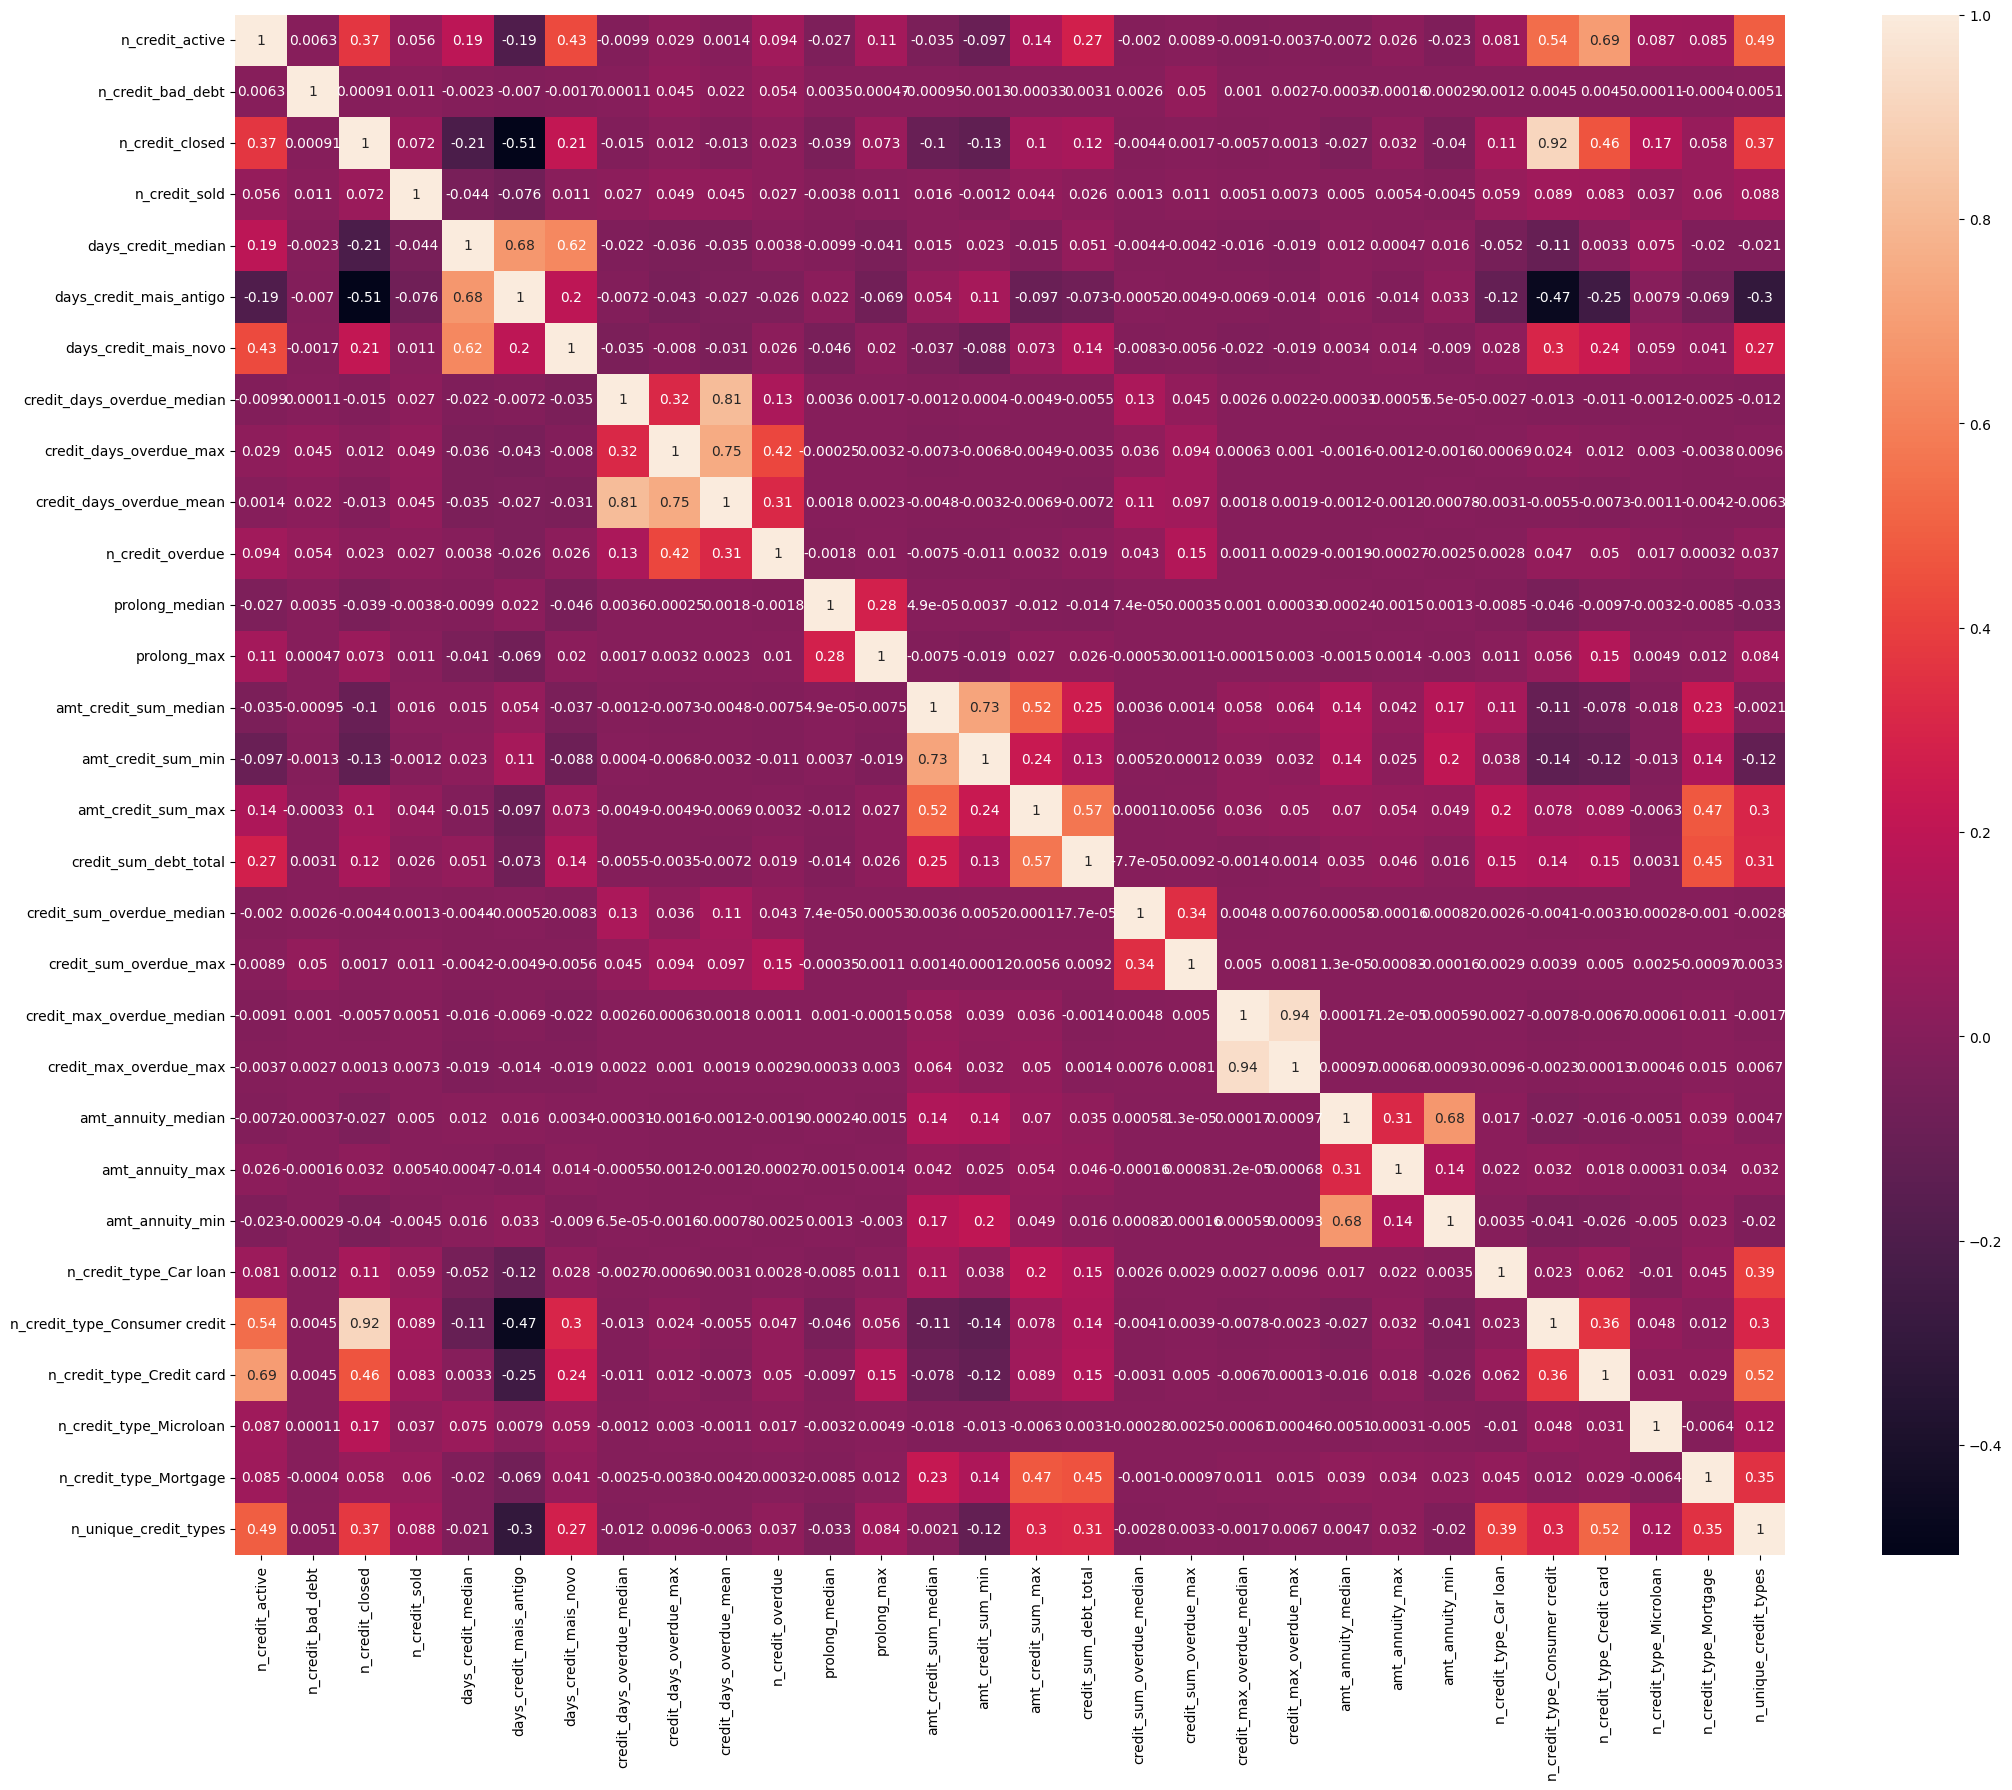

In [58]:
plt.figure(figsize=(25,20))
sns.heatmap(bureau_agg.corr(), annot=True)

VIF

In [59]:
process_vif = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='median'), numericas)
])

In [60]:
process_vif.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{featur

In [61]:
bureau_imputadas = process_vif.fit_transform(bureau_agg)

Aplicação do VIF

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [63]:
vif_df = pd.DataFrame({
    'feature':bureau_imputadas.columns,
    'VIF':[
        variance_inflation_factor(bureau_imputadas.values, i)
        for i in range(bureau_imputadas.shape[1])
    ]
})

In [64]:
vif_df.sort_values(by='VIF', ascending=False)

,feature,VIF
25,imputer__n_credit_type_Consumer credit,1363.707502
2,imputer__n_credit_closed,1128.987391
0,imputer__n_credit_active,356.024451
26,imputer__n_credit_type_Credit card,188.458389
5,imputer__days_credit_mais_antigo,15.095962
27,imputer__n_credit_type_Microloan,14.891296
9,imputer__credit_days_overdue_mean,14.206022
4,imputer__days_credit_median,14.039737
20,imputer__credit_max_overdue_max,9.016049
19,imputer__credit_max_overdue_median,9.003742


Testando sinal

In [65]:
from sklearn.ensemble import ExtraTreesClassifier

In [66]:
dataset_application = pd.read_csv(r'C:\Projects_ciência_dados\project_credit_risk\data\raw\home-credit-default-risk\application_train.csv')

In [67]:
target = pd.DataFrame({
    'target':dataset_application['TARGET'],
    'SK_ID_CURR':dataset_application['SK_ID_CURR']
})

In [68]:
bureau_target = pd.DataFrame()
bureau_target = bureau_processed_others.merge(target, how='left', on='SK_ID_CURR')

In [69]:
bureau_target

,SK_ID_CURR,imputer__n_credit_active,imputer__n_credit_bad_debt,imputer__n_credit_closed,imputer__n_credit_sold,imputer__days_credit_median,imputer__days_credit_mais_antigo,imputer__days_credit_mais_novo,imputer__credit_days_overdue_median,imputer__credit_days_overdue_max,...,imputer__amt_annuity_median,imputer__amt_annuity_max,imputer__amt_annuity_min,imputer__n_credit_type_Car loan,imputer__n_credit_type_Consumer credit,imputer__n_credit_type_Credit card,imputer__n_credit_type_Microloan,imputer__n_credit_type_Mortgage,imputer__n_unique_credit_types,target
0,100001,3.0,0.0,4.0,0.0,-857.0,-1572.0,-49.0,0.0,0.0,...,0.0,10822.5,0.000,0.0,7.0,0.0,0.0,0.0,1.0,NaN
1,100002,2.0,0.0,6.0,0.0,-1042.5,-1437.0,-103.0,0.0,0.0,...,0.0,0.0,0.000,0.0,4.0,4.0,0.0,0.0,2.0,1.0
2,100003,1.0,0.0,3.0,0.0,-1205.5,-2586.0,-606.0,0.0,0.0,...,2970.0,13500.0,0.000,0.0,2.0,2.0,0.0,0.0,2.0,0.0
3,100004,0.0,0.0,2.0,0.0,-867.0,-1326.0,-408.0,0.0,0.0,...,2970.0,13500.0,0.000,0.0,2.0,0.0,0.0,0.0,1.0,0.0
4,100005,2.0,0.0,1.0,0.0,-137.0,-373.0,-62.0,0.0,0.0,...,0.0,4261.5,0.000,0.0,2.0,1.0,0.0,0.0,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,2.0,0.0,11.0,0.0,-1680.0,-2713.0,-483.0,0.0,0.0,...,2970.0,13500.0,0.000,0.0,9.0,3.0,0.0,0.0,3.0,0.0
305807,456250,2.0,0.0,1.0,0.0,-824.0,-1002.0,-760.0,0.0,0.0,...,51799.5,384147.0,27757.395,0.0,2.0,1.0,0.0,0.0,2.0,NaN
305808,456253,2.0,0.0,2.0,0.0,-919.0,-919.0,-713.0,0.0,0.0,...,58369.5,58369.5,58369.500,0.0,3.0,1.0,0.0,0.0,2.0,0.0
305809,456254,0.0,0.0,1.0,0.0,-1104.0,-1104.0,-1104.0,0.0,0.0,...,0.0,0.0,0.000,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [70]:
bureau_target.loc[bureau_target['target'].isnull()].shape[0]

42320

13% do target é nulo, portanto é preciso eliminar essas linhas para não criar rótulos artificias que geram ruídos no modelo

In [71]:
(42320/305811) * 100

13.838612737932907

Apagando linhas de target nulas

In [72]:
bureau_target = bureau_target[bureau_target['target'].notna()]

In [73]:
bureau_target.loc[bureau_target['target'].isnull()].shape[0]

0

Separação entre variáveis previsoras e classe 

In [74]:
x = bureau_target.drop(['target','SK_ID_CURR'], axis = 1)
y = bureau_target['target']

In [75]:
extra = ExtraTreesClassifier()
extra.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [76]:
importance = pd.DataFrame({
    'feature':x.columns,
    'importancia':extra.feature_importances_
}).sort_values(by='importancia', ascending=False)
importance

,feature,importancia
4,imputer__days_credit_median,0.098009
5,imputer__days_credit_mais_antigo,0.095982
6,imputer__days_credit_mais_novo,0.094301
13,imputer__amt_credit_sum_median,0.090236
15,imputer__amt_credit_sum_max,0.089301
14,imputer__amt_credit_sum_min,0.085860
16,imputer__credit_sum_debt_total,0.079019
20,imputer__credit_max_overdue_max,0.045777
25,imputer__n_credit_type_Consumer credit,0.041796
22,imputer__amt_annuity_max,0.041215


In [77]:
importance['importancia'].median()

np.float64(0.024392549491057312)

In [78]:
(importance['importancia'].quantile(0.75)) - (importance['importancia'].quantile(0.25))

np.float64(0.041703707430273074)

In [79]:
feature_abaixo_threshold

,num__amt_credit_sum_max,num__credit_sum_overdue_median,num__credit_sum_overdue_max,num__credit_max_overdue_median,num__credit_max_overdue_max,num__amt_annuity_median,num__amt_annuity_max,num__amt_annuity_min
SK_ID_CURR,,,,,,,,
100001,0.000646,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000091,0.000000
100002,0.000769,0.0,0.0,3.491765e-07,0.000043,0.000000,0.000000,0.000000
100003,0.001385,0.0,0.0,0.000000e+00,0.000000,0.000109,0.000114,0.000000
100004,0.000162,0.0,0.0,0.000000e+00,0.000000,0.000109,0.000114,0.000000
100005,0.000972,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000036,0.000000
...,...,...,...,...,...,...,...,...
456249,0.001308,0.0,0.0,0.000000e+00,0.000163,0.000109,0.000114,0.000000
456250,0.003681,0.0,0.0,0.000000e+00,0.000000,0.001899,0.003243,0.001156
456253,0.003846,0.0,0.0,0.000000e+00,0.000000,0.002139,0.000493,0.002430


In [80]:
var_bureau

num__credit_max_overdue_median        0.000004
num__amt_annuity_min                  0.000005
num__credit_max_overdue_max           0.000006
num__credit_sum_overdue_median        0.000006
num__amt_annuity_median               0.000009
num__amt_annuity_max                  0.000011
num__credit_sum_overdue_max           0.000013
num__amt_credit_sum_max               0.000016
num__amt_credit_sum_min               0.000016
num__amt_credit_sum_median            0.000017
num__credit_sum_debt_total            0.000023
num__n_credit_type_Microloan          0.000048
num__credit_days_overdue_median       0.000055
num__n_credit_bad_debt                0.000069
num__prolong_median                   0.000073
num__credit_days_overdue_mean         0.000081
num__n_credit_sold                    0.000309
num__n_credit_overdue                 0.000347
num__n_credit_type_Mortgage           0.000405
num__prolong_max                      0.000615
num__credit_days_overdue_max          0.000939
num__n_credit

In [81]:
len(var_bureau)

30

AMT_ANNUITY MIN deve ser deletada, pois apresenta baixa variação, apresenta alta correlação com annuity median e menor poder preditivo que annuity median e max

Low variance supõe, Extra Trees decide

Decidir o que irei fazer com esse arquivo em relação aos commits

imputer__credit_max_overdue_median deve ser excluída pelos seguintes motivos:

- Apresenta variação abaixo do Threshold de 0.000016, que é 79,22% menor que a mediana e 99,9% menor que a variação máxima. Além de ser a feature que menor variação entre todas

- Correlação muita alta (0.94) com outra feature (imputer__credit_max_overdue_max), o que a torna redundante

- Importância menor que a feature muito parecida (imputer__credit_max_overdue_max)


num__credit_sum_overdue_median deve ser excluída pelos seguintes motivos:

- Apresenta variação abaixo do Threshold de 0.000016, que é 79,22% menor que a mediana e 99,9% menor que a variação máxima. Além de ser a 4º feature com a menor variação

- É a 4º feature com a pior importância

imputer__n_credit_bad_debt deve ser excluída pelo seguinte motivo:

- Apresenta a pior importâcia entre as features 


	


imputer__credit_days_overdue_median deve ser excluída pelos seguintes motivos:

- Apresenta a 2º pior importância

- Entre as métricas de credit_days_overdue ela apresenta a pior importância

- Apresenta alta correlação com credit_days_overdue_mean (0.81)

prolong_median deve ser excluída pelos seguintes motivos:

- É 90,54% menos importante que prolong_max e eventos extremos (max) são mais discriminativos

- 4º pior importância no geral

Excluindo essas 6 colunas

In [82]:
bureau_target_excluidas = bureau_target.drop([
    'imputer__prolong_median',
    'imputer__credit_days_overdue_median',
    'imputer__n_credit_bad_debt',
    'imputer__credit_sum_overdue_median',
    'imputer__credit_max_overdue_median',
    'imputer__amt_annuity_min'
    
    ], axis = 1)

In [83]:
x = bureau_target_excluidas.drop(['target','SK_ID_CURR'], axis = 1)
y = bureau_target_excluidas['target']

In [84]:
extra.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [85]:
importance_novo = pd.DataFrame({
    'Feature':x.columns,
    'Importância':extra.feature_importances_
}).sort_values(by='Importância', ascending=False)
importance_novo

,Feature,Importância
3,imputer__days_credit_median,0.101017
4,imputer__days_credit_mais_antigo,0.099885
5,imputer__days_credit_mais_novo,0.098109
10,imputer__amt_credit_sum_median,0.093824
12,imputer__amt_credit_sum_max,0.092835
11,imputer__amt_credit_sum_min,0.089772
13,imputer__credit_sum_debt_total,0.083103
15,imputer__credit_max_overdue_max,0.059057
16,imputer__amt_annuity_median,0.047386
17,imputer__amt_annuity_max,0.047290


In [86]:
importance

,feature,importancia
4,imputer__days_credit_median,0.098009
5,imputer__days_credit_mais_antigo,0.095982
6,imputer__days_credit_mais_novo,0.094301
13,imputer__amt_credit_sum_median,0.090236
15,imputer__amt_credit_sum_max,0.089301
14,imputer__amt_credit_sum_min,0.085860
16,imputer__credit_sum_debt_total,0.079019
20,imputer__credit_max_overdue_max,0.045777
25,imputer__n_credit_type_Consumer credit,0.041796
22,imputer__amt_annuity_max,0.041215


Comparação de mediana

In [87]:
importance['importancia'].median()

np.float64(0.024392549491057312)

In [88]:
importance_novo['Importância'].median()

np.float64(0.0368832091547424)

Comparação de diferença interquartílica

In [89]:
(importance['importancia'].quantile(0.75)) - (importance['importancia'].quantile(0.25))

np.float64(0.041703707430273074)

In [90]:
(importance_novo['Importância'].quantile(0.75)) - (importance_novo['Importância'].quantile(0.25))

np.float64(0.08001492140074927)

Comparação de mais medidas

In [91]:
importance['importancia'].describe()

count    30.000000
mean      0.033333
std       0.035466
min       0.000050
25%       0.003078
50%       0.024393
75%       0.044782
max       0.098009
Name: importancia, dtype: float64

In [92]:
importance_novo['Importância'].describe()

count    24.000000
mean      0.041667
std       0.038499
min       0.001932
25%       0.004756
50%       0.036883
75%       0.084771
max       0.101017
Name: Importância, dtype: float64

- Após as exclusões, a mediana da importância aumentou 49,5%

- Todos percentis estão mais altos, principalmente o 75º. Evidenciando que as features mais importantes garantiram mais protagonismo

- O aumento da distância interquartílica indica que os dados estão mais dispersos, mas as importâncias estão maiores, ou seja, houve uma maior diferenciação entre as features boas e as medianas

#### Respondendo perguntas de negócio

Pessoas com muitos créditos ativos tem mais riscos?

In [93]:
np.unique(bureau_target['imputer__n_credit_active'], return_counts=True)

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 22., 32.]),
 array([46341, 74103, 58383, 38011, 22041, 12051,  6107,  3156,  1648,
          780,   425,   220,   111,    51,    27,    14,     5,     7,
            2,     4,     1,     2,     1]))

<Axes: xlabel='imputer__n_credit_active', ylabel='target'>

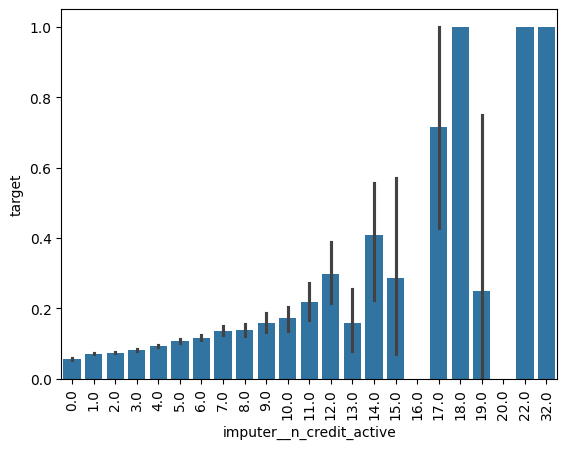

In [94]:
plt.xticks(rotation=90)
sns.barplot(data=bureau_target, x='imputer__n_credit_active', y='target')

In [95]:
np.unique(bureau_target['imputer__n_unique_credit_types'], return_counts=True)

(array([1., 2., 3., 4., 5., 6.]),
 array([ 94669, 143720,  23298,   1735,     65,      4]))

<Axes: xlabel='imputer__n_unique_credit_types', ylabel='target'>

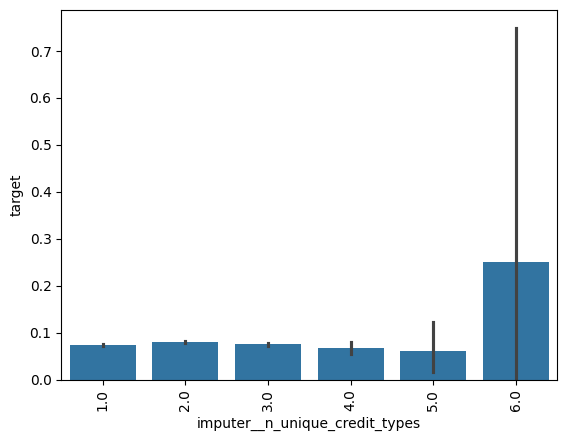

In [96]:
plt.xticks(rotation=90)
sns.barplot(data=bureau_target, x='imputer__n_unique_credit_types', y='target')

Diversificação do crédito

In [97]:
diversificacao_credito = pd.DataFrame({
    'diversificacao': bureau_target['imputer__n_unique_credit_types'] / bureau_target['imputer__n_credit_active'] ,
    'target': bureau_target['target']
})

<Axes: xlabel='diversificacao', ylabel='target'>

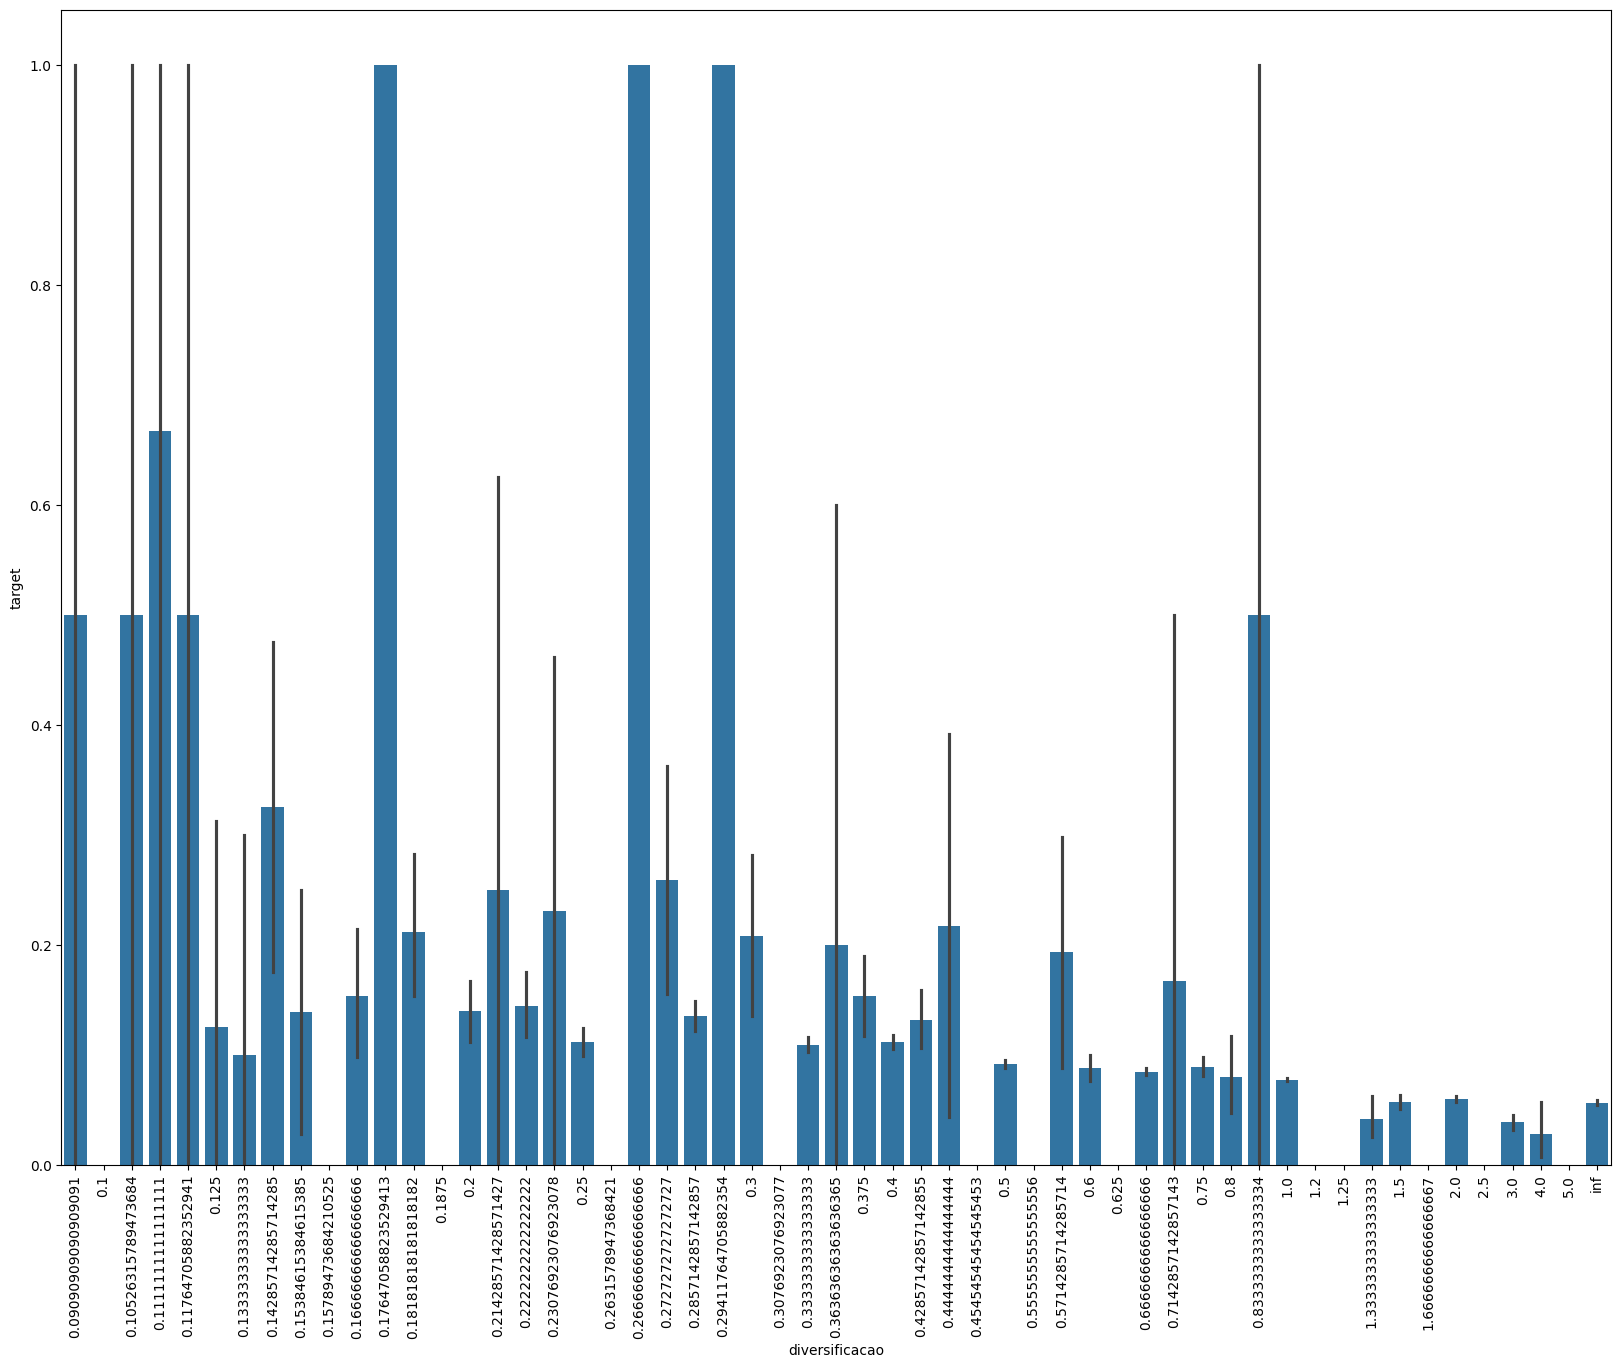

In [98]:
plt.figure(figsize=(20,15))
plt.xticks(rotation=90)
sns.barplot(data=diversificacao_credito, x='diversificacao', y='target')

Fracasso, revisar

Ter muitos créditos fechados indica experiência financeira ou histórico problemático?

In [99]:
np.unique(bureau_target['imputer__n_credit_closed'], return_counts=True)

(array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
         11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
         22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
         33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
         44.,  45.,  46.,  47.,  48.,  51.,  52.,  56.,  84., 108.]),
 array([33326, 53505, 43091, 33669, 25914, 19641, 14610, 10919,  7651,
         5635,  4156,  3073,  2195,  1674,  1183,   880,   617,   431,
          319,   244,   173,   133,    84,    88,    58,    52,    29,
           27,    18,    17,    10,     8,     9,     5,     2,     6,
            4,     2,     1,     4,     5,     1,     3,     2,     1,
            1,     2,     3,     4,     1,     2,     1,     1,     1]))

<Axes: xlabel='imputer__n_credit_closed', ylabel='target'>

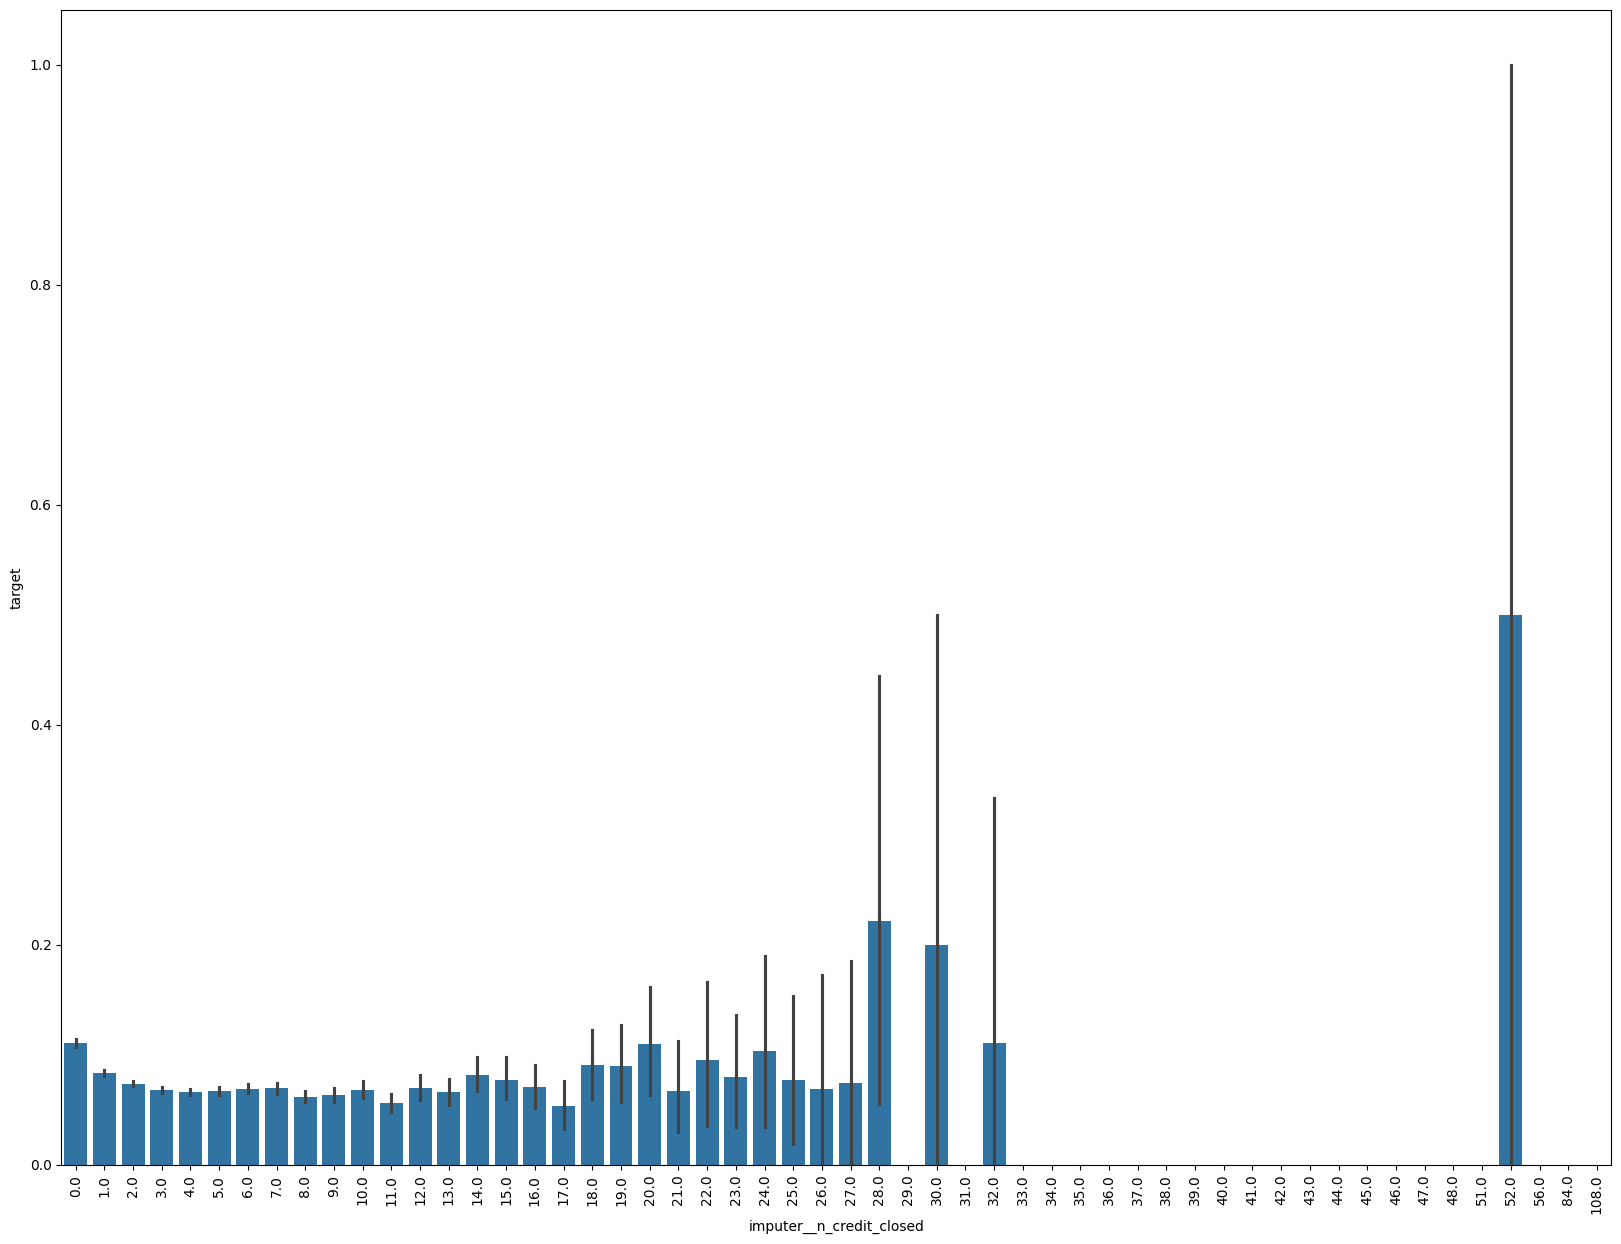

In [100]:
plt.figure(figsize=(20,15))
plt.xticks(rotation=90)
sns.barplot(data=bureau_target, x='imputer__n_credit_closed', y='target')

<Axes: xlabel='target', ylabel='imputer__n_credit_closed'>

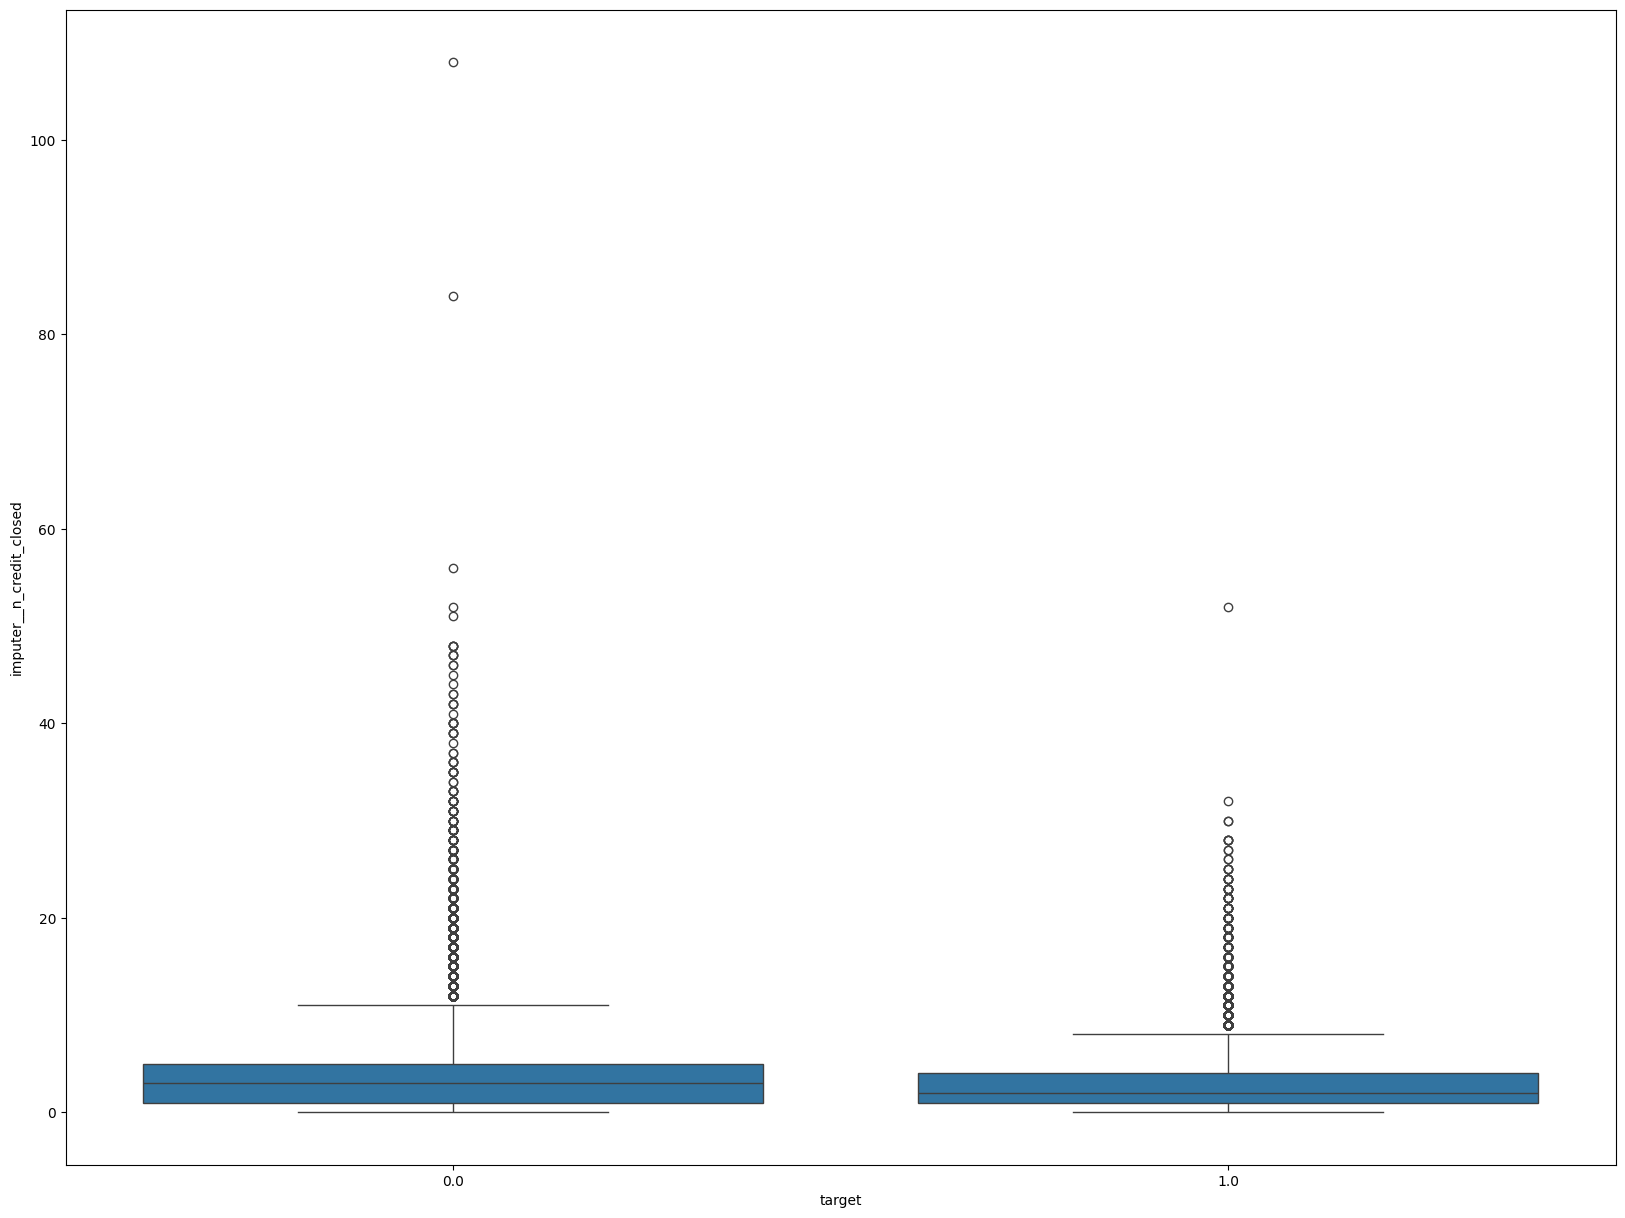

In [101]:
plt.figure(figsize=(20,15))
sns.boxplot(data=bureau_target, x='target', y='imputer__n_credit_closed')

Pessoas não inadimplentes tem em média maior número de créditos fechados

Proporção de créditos fechados e abertos

In [102]:
fechado_ativo = pd.DataFrame({
    'proporcao': bureau_target['imputer__n_credit_closed'] / (bureau_target['imputer__n_credit_active'] + 1),
    'target':bureau_target['target']
})

In [103]:
mais_ativo_que_fechado = fechado_ativo.loc[fechado_ativo['proporcao'] < 1]

In [104]:
mais_ativo_que_fechado.loc[mais_ativo_que_fechado['target'] == 1].shape[0]

10829

In [105]:
def serializacao(n: int) -> str:
    if n < 1:
        return 'mais_ativo_que_fechado'
    elif n > 1:
        return 'mais_fechado_que_ativo'
    else:
        return 'quantidades_iguais'

In [106]:
serializacao_fechado_ativo = pd.DataFrame({
    'rotulos': fechado_ativo['proporcao'].apply(serializacao),
    'target': fechado_ativo['target']
})

<Axes: xlabel='rotulos', ylabel='target'>

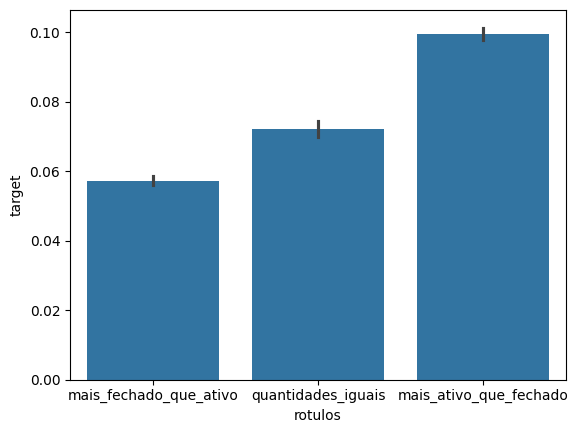

In [107]:
sns.barplot(data=serializacao_fechado_ativo, x='rotulos', y='target')

<Axes: xlabel='rotulos', ylabel='count'>

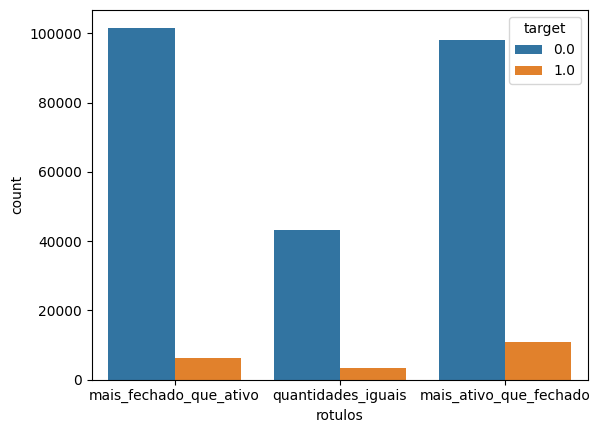

In [108]:
sns.countplot(data=serializacao_fechado_ativo, x='rotulos', hue='target')

Pessoas que possuem mais créditos ativos que fechados, possuem mais risco de inadimplência

#### Pergunta: o risco está no valor emprestado ou no valor ainda devido?

<Axes: xlabel='imputer__credit_sum_debt_total', ylabel='imputer__amt_credit_sum_max'>

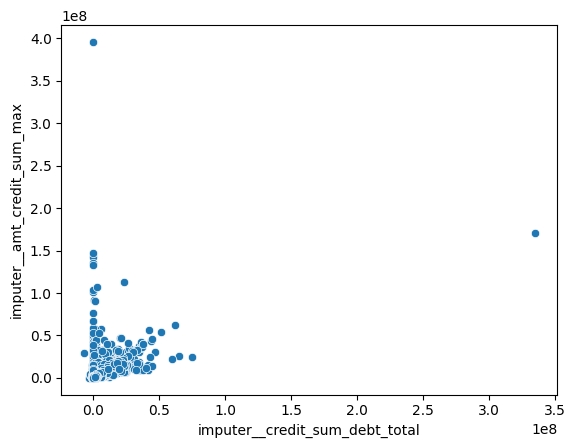

In [109]:
sns.scatterplot(x=bureau_target['imputer__credit_sum_debt_total'], y=bureau_target['imputer__amt_credit_sum_max'])

Dps

#### Perguntas:

> Quantidade de atrasos importa mais que intensidade?
> 
> 
> A média de atraso importa mais que o máximo?
>

<Axes: xlabel='imputer__credit_days_overdue_mean', ylabel='imputer__credit_days_overdue_max'>

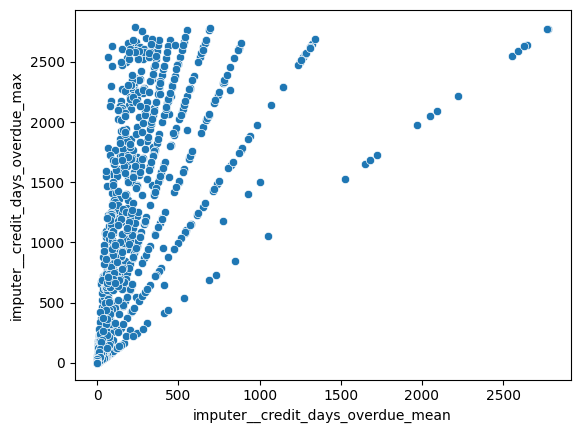

In [110]:
sns.scatterplot(data=bureau_target, x='imputer__credit_days_overdue_mean', y='imputer__credit_days_overdue_max')

In [111]:
bureau_target.groupby('target')['imputer__credit_days_overdue_mean'].mean()

target
0.0    0.975178
1.0    1.760230
Name: imputer__credit_days_overdue_mean, dtype: float64

In [112]:
bureau_target.groupby('target')['imputer__credit_days_overdue_max'].mean()

target
0.0    4.631043
1.0    6.464356
Name: imputer__credit_days_overdue_max, dtype: float64

In [113]:
bureau_target.groupby('target')[[
    'imputer__credit_days_overdue_mean',
    'imputer__credit_days_overdue_max'
]].mean()

,imputer__credit_days_overdue_mean,imputer__credit_days_overdue_max
target,,
0.0,0.975178,4.631043
1.0,1.760230,6.464356


In [ ]:
bureau_target['overdue_ratio'] = (
    bureau_target['imputer__credit_days_overdue_max'] /
    (bureau_target['imputer__credit_days_overdue_mean'])
)

C:\Users\pgssd\AppData\Local\Temp\ipykernel_6728\1975543545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bureau_target['overdue_ratio'] = (


In [ ]:
bureau_target.groupby('target')['overdue_ratio'].mean()

target
0.0    7.352648
1.0    7.278674
Name: overdue_ratio, dtype: float64

 - A média de atrasos de pessoas inadimplentes é 80,5% maior que adimplentes, enquanto os atrasos máximos são 39,6% maiores. 

 - O ratio entre max e mean permanece quase igual.

 - Inadimplentes apresentam maiores níveis absolutos tanto de atraso médio quanto máximo.

 - Ou seja, a recorrência de atrasos é mais preditivo que atrasos extremos.